<a href="https://colab.research.google.com/github/suhani242/T170800236_TNS_AIML/blob/main/AIML_day15_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


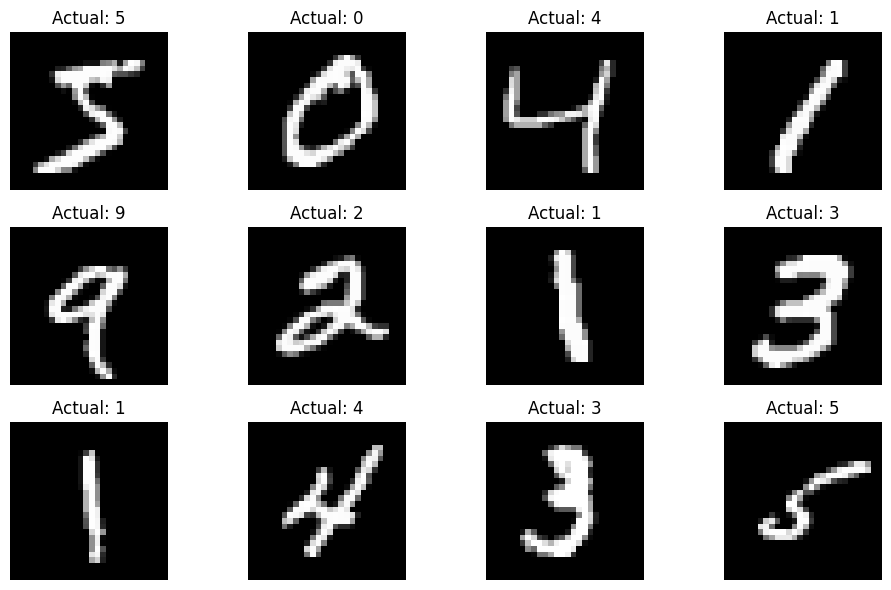

Pixel values are now between: 0.0 and 1.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


========== TRAINING CNN ==========

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9246 - loss: 0.2568 - val_accuracy: 0.9752 - val_loss: 0.0829
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9785 - loss: 0.0690 - val_accuracy: 0.9845 - val_loss: 0.0515
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9849 - loss: 0.0490 - val_accuracy: 0.9873 - val_loss: 0.0458
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9881 - loss: 0.0383 - val_accuracy: 0.9847 - val_loss: 0.0505
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9905 - loss: 0.0306 - val_accuracy: 0.9895 - val_loss: 0.0365

========== TESTING CNN ==========

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9891 - loss: 0.0318

Test Loss     : 0.03181976452469826
Test Accuracy : 0.9890999794006348


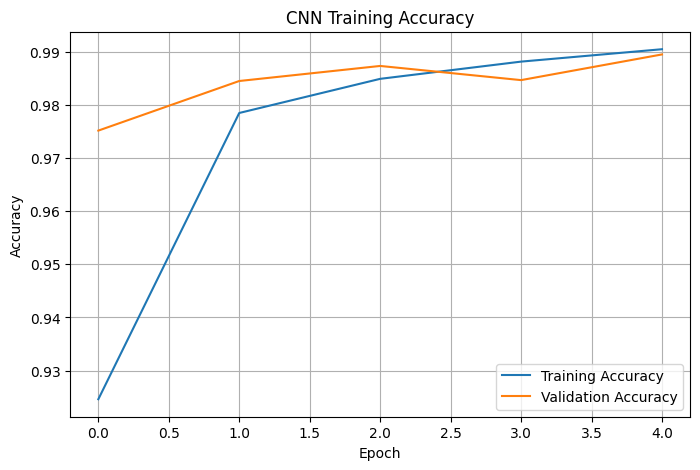

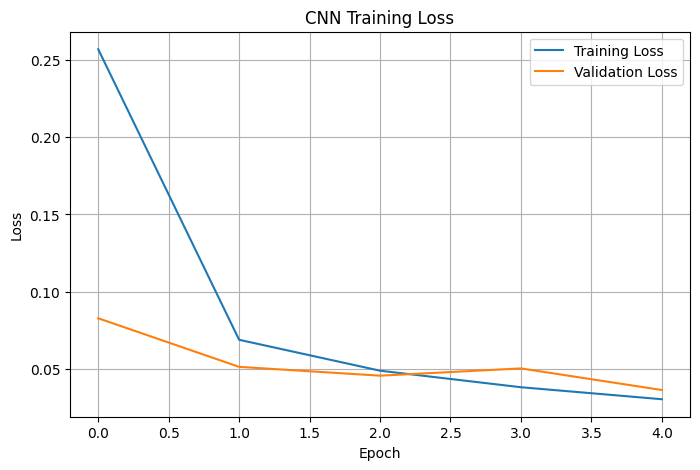


========== MAKING PREDICTIONS ==========

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


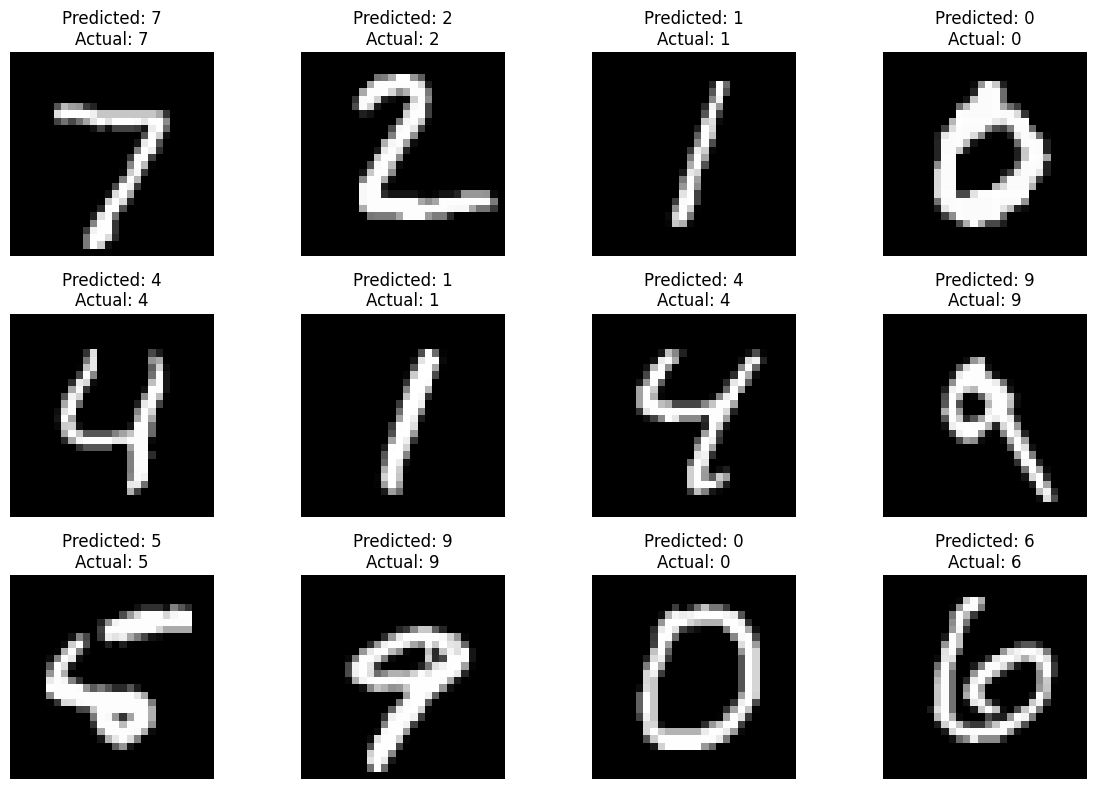

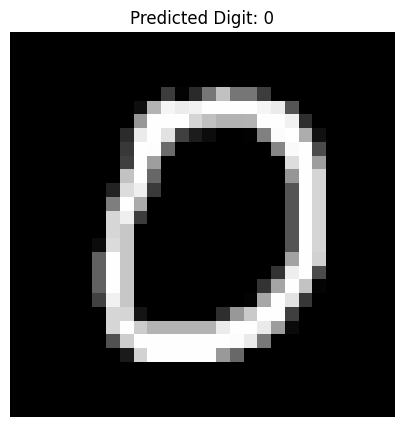


Class Probabilities:

Digit 0 : 100.00%
Digit 1 : 0.00%
Digit 2 : 0.00%
Digit 3 : 0.00%
Digit 4 : 0.00%
Digit 5 : 0.00%
Digit 6 : 0.00%
Digit 7 : 0.00%
Digit 8 : 0.00%
Digit 9 : 0.00%

       CNN DIGIT RECOGNITION
Test Accuracy : 98.91%
Example Prediction : 0


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


from tensorflow.keras import layers, models

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)
class_names = [
    '0', '1', '2', '3', '4',
    '5', '6', '7', '8', '9'
]



plt.figure(figsize=(10, 6))

for i in range(12):

    plt.subplot(3, 4, i + 1)


    plt.imshow(X_train[i], cmap='gray')
    plt.title("Actual: " + class_names[y_train[i]])


    plt.axis('off')

plt.tight_layout()
plt.show()
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Pixel values are now between:",
      X_train.min(), "and", X_train.max())



model = models.Sequential([



    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
     layers.MaxPooling2D((2, 2)),

     layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),



    layers.MaxPooling2D((2, 2)),




    layers.Flatten(),



    layers.Dense(
        64,
        activation='relu'
    ),



    layers.Dense(
        10,
        activation='softmax'
    )


])



model.summary()




model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)







print("\n========== TRAINING CNN ==========\n")

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=128
)



print("\n========== TESTING CNN ==========\n")

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training Accuracy')

plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training Loss')

plt.legend()
plt.grid(True)
plt.show()



print("\n========== MAKING PREDICTIONS ==========\n")

predictions = model.predict(X_test)

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap='gray'
    )



    predicted_class = np.argmax(predictions[i])

    actual_class = y_test[i]

    predicted_name = class_names[predicted_class]
    actual_name = class_names[actual_class]

    plt.title(
        f"Predicted: {predicted_name}\n"
        f"Actual: {actual_name}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()
index = 10



plt.figure(figsize=(5, 5))

plt.imshow(
    X_test[index].reshape(28, 28),
    cmap='gray'
)

plt.axis('off')

predicted_class = np.argmax(predictions[index])

plt.title(
    f"Predicted Digit: {class_names[predicted_class]}"
)

plt.show()


print("\nClass Probabilities:\n")

for i in range(10):

    print(
        f"Digit {class_names[i]} : "
        f"{predictions[index][i] * 100:.2f}%"
    )

print("\n======================================")
print("       CNN DIGIT RECOGNITION")
print("======================================")

print(
    "Test Accuracy :",
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Example Prediction :",
    class_names[np.argmax(predictions[index])]
)

print("======================================")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1701s 10us/step
Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)


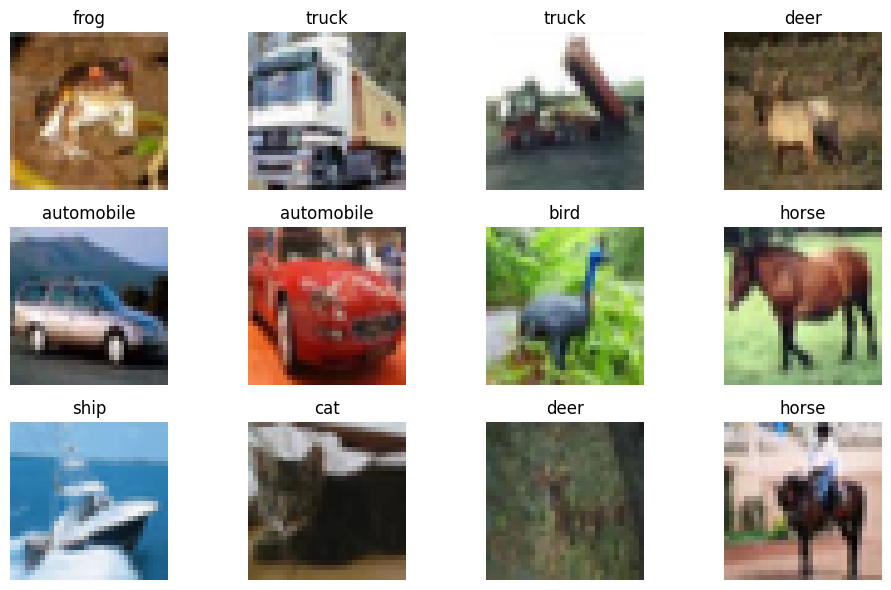

Pixel values are now between: 0.0 and 1.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


========== TRAINING CNN ==========

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3872 - loss: 1.6731 - val_accuracy: 0.5218 - val_loss: 1.3656
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5340 - loss: 1.3038 - val_accuracy: 0.5778 - val_loss: 1.1915
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5912 - loss: 1.1605 - val_accuracy: 0.6134 - val_loss: 1.1020
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6276 - loss: 1.0607 - val_accuracy: 0.6418 - val_loss: 1.0144
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6530 - loss: 0.9910 - val_accuracy: 0.6580 - val_loss: 0.9762

========== TESTING CNN ==========

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6548 - loss: 0.9900

Test Loss     : 0.9900402426719666
Test Accuracy : 0.6547999978065491


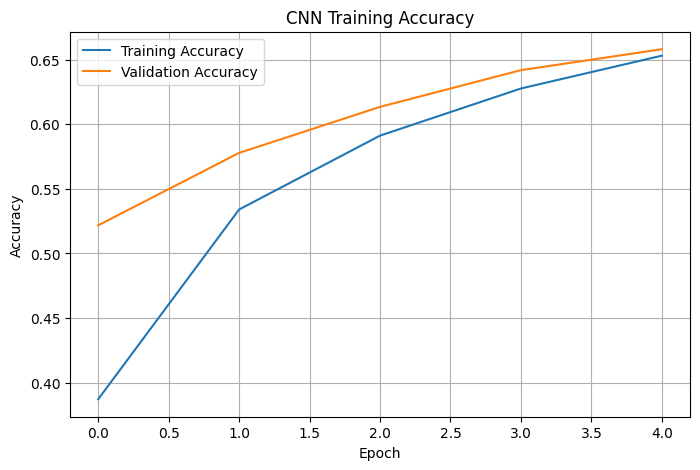

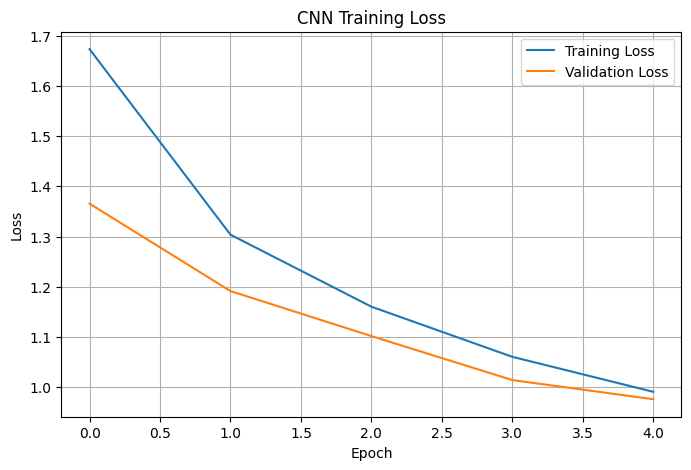


========== MAKING PREDICTIONS ==========

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


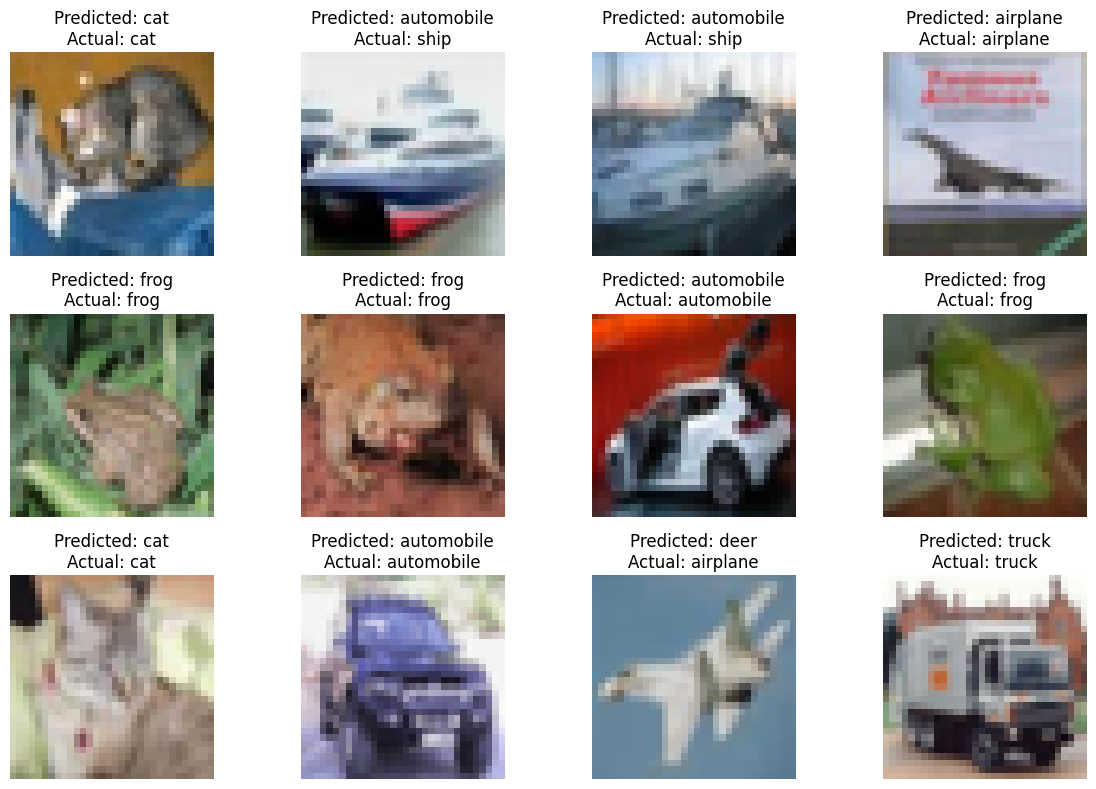

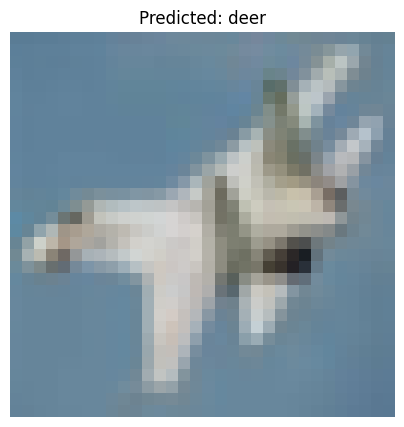


Class Probabilities:

airplane     : 17.96%
automobile   : 0.24%
bird         : 3.90%
cat          : 1.47%
deer         : 69.98%
dog          : 1.41%
frog         : 0.08%
horse        : 3.63%
ship         : 1.12%
truck        : 0.20%

        CNN IMAGE RECOGNITION
Test Accuracy : 65.48%
Example Prediction : deer


In [ ]:


import tensorflow as tf


import numpy as np


import matplotlib.pyplot as plt


from tensorflow.keras import layers, models


(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()



print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)




class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]



plt.figure(figsize=(10, 6))

for i in range(12):

    plt.subplot(3, 4, i + 1)


    plt.imshow(X_train[i])


    plt.title(class_names[y_train[i][0]])


    plt.axis('off')


plt.tight_layout()
plt.show()




X_train = X_train / 255.0
X_test = X_test / 255.0

print("Pixel values are now between:",
      X_train.min(), "and", X_train.max())




    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),



    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),



    layers.MaxPooling2D((2, 2)),




    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),



    layers.Flatten(),

    layers.Dense(
        64,
        activation='relu'
    ),



    layers.Dense(
        10,
        activation='softmax'
    )
model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)




print("\n========== TRAINING CNN ==========\n")

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=128
)



print("\n========== TESTING CNN ==========\n")

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)


plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training Accuracy')

plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training Loss')

plt.legend()
plt.grid(True)
plt.show()


print("\n========== MAKING PREDICTIONS ==========\n")

predictions = model.predict(X_test)


plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i])



    predicted_class = np.argmax(predictions[i])


    actual_class = y_test[i][0]



    predicted_name = class_names[predicted_class]
    actual_name = class_names[actual_class]

    plt.title(
        f"Predicted: {predicted_name}\nActual: {actual_name}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()


index = 10


plt.figure(figsize=(5, 5))

plt.imshow(X_test[index])

plt.axis('off')

predicted_class = np.argmax(predictions[index])

plt.title(
    f"Predicted: {class_names[predicted_class]}"
)

plt.show()


print("\nClass Probabilities:\n")

for i in range(10):

    print(
        f"{class_names[i]:12s} : "
        f"{predictions[index][i] * 100:.2f}%"
    )


print("\n======================================")
print("        CNN IMAGE RECOGNITION")
print("======================================")

print("Test Accuracy :", f"{test_accuracy * 100:.2f}%")

print(
    "Example Prediction :",
    class_names[np.argmax(predictions[index])]
)

print("======================================")